In [1]:
pip install scikit-learn


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


In [6]:
df = pd.read_csv("/Users/angel/Desktop/forecast/Nifty50-Forecasting/nifty_final_dataset.csv")

df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')
df.set_index('date', inplace=True)

print(df.shape)
df.head()

(1848, 84)


,close,high,low,open,volume,log_ret,ret_1,ret_5,ret_15,vol_5,...,sector_mean,sector_std,strongest_sector,bank_ret_vs_nifty,it_ret_vs_nifty,pharma_ret_vs_nifty,auto_ret_vs_nifty,fmcg_ret_vs_nifty,metal_ret_vs_nifty,energy_ret_vs_nifty
date,,,,,,,,,,,,,,,,,,,,,
2018-01-30,11049.650391,11121.099609,11033.900391,11120.849609,228000,-0.007281,-0.007255,0.007610,0.040104,0.006843,...,-0.005341,0.003364,energy_ret,-0.001087,-0.002906,0.001144,0.002931,0.005613,0.001314,0.006386
2018-01-31,11027.700195,11058.500000,10979.299805,11018.799805,245900,-0.001988,-0.001987,-0.005052,0.036730,0.004583,...,-0.006512,0.009468,energy_ret,0.006035,-0.007286,-0.016709,0.000611,-0.012000,-0.010258,0.007930
2018-02-01,11016.900391,11117.349609,10878.799805,11044.549805,306200,-0.000980,-0.000979,-0.006233,0.036183,0.004534,...,-0.004005,0.011527,fmcg_ret,-0.004819,-0.000699,-0.023108,0.008015,0.009259,0.002344,-0.012169
2018-02-02,10760.599609,10954.950195,10736.099609,10938.200195,282700,-0.023539,-0.023264,-0.027919,0.010271,0.010973,...,-0.020533,0.014487,it_ret,-0.005006,0.024730,0.010604,-0.010228,0.016983,-0.006971,-0.010990
2018-02-05,10666.549805,10702.750000,10586.799805,10604.299805,240100,-0.008779,-0.008740,-0.041674,-0.001376,0.009037,...,-0.001745,0.006641,auto_ret,-0.004582,0.005143,0.011698,0.016212,0.009167,0.003232,0.008094


In [7]:
target_col = 'target'

# Strong exogenous variables (don’t overload!)
exog_cols = [
    'bank_ret_lag1', 'it_ret_lag1', 'pharma_ret_lag1',
    'auto_ret_lag1', 'fmcg_ret_lag1', 'metal_ret_lag1',
    'energy_ret_lag1',
    'vol_5', 'momentum', 'trend_strength'
]

df = df.dropna()

y = df[target_col]
X = df[exog_cols]

In [8]:
split = int(len(df) * 0.8)

y_train, y_test = y[:split], y[split:]
X_train, X_test = X[:split], X[split:]

print(len(y_train), len(y_test))

1478 370


## SARIMA Model

In [9]:
sarima_model = SARIMAX(
    y_train,
    order=(1,0,1),
    seasonal_order=(1,0,1,5),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_fit = sarima_model.fit(disp=False)

print(sarima_fit.summary())

/opt/homebrew/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/homebrew/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                     
Dep. Variable:                            target   No. Observations:                 1478
Model:             SARIMAX(1, 0, 1)x(1, 0, 1, 5)   Log Likelihood                4499.242
Date:                           Thu, 07 May 2026   AIC                          -8988.483
Time:                                   10:40:56   BIC                          -8962.015
Sample:                                        0   HQIC                         -8978.613
                                          - 1478                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3717      0.116     -3.205      0.001      -0.599      -0.144
ma.L1          0.3062      0.122      2.502

In [10]:
sarima_forecast = sarima_fit.get_forecast(steps=len(y_test))

sarima_pred = sarima_forecast.predicted_mean
sarima_ci = sarima_forecast.conf_int()

/opt/homebrew/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/opt/homebrew/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [11]:
sarimax_model = SARIMAX(
    y_train,
    exog=X_train,
    order=(1,0,1),
    seasonal_order=(1,0,1,5),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarimax_fit = sarimax_model.fit(disp=False)

print(sarimax_fit.summary())

/opt/homebrew/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/homebrew/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                     
Dep. Variable:                            target   No. Observations:                 1478
Model:             SARIMAX(1, 0, 1)x(1, 0, 1, 5)   Log Likelihood                4503.850
Date:                           Thu, 07 May 2026   AIC                          -8977.700
Time:                                   10:41:15   BIC                          -8898.294
Sample:                                        0   HQIC                         -8948.090
                                          - 1478                                         
Covariance Type:                             opg                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
bank_ret_lag1      -0.0456      0.038     -1.213      0.225      -0.119       0.028
it_ret_lag1         0.0396  

/opt/homebrew/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [12]:
sarimax_forecast = sarimax_fit.get_forecast(
    steps=len(y_test),
    exog=X_test
)

sarimax_pred = sarimax_forecast.predicted_mean
sarimax_ci = sarimax_forecast.conf_int()

/opt/homebrew/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/opt/homebrew/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [13]:
def evaluate(y_true, y_pred, ci):
    
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    lower = ci.iloc[:, 0]
    upper = ci.iloc[:, 1]
    
    # Prediction Interval Coverage Probability
    picp = ((y_true >= lower) & (y_true <= upper)).mean()
    
    # Mean Prediction Interval Width
    mpiw = (upper - lower).mean()
    
    return rmse, mae, r2, picp, mpiw

In [14]:
def evaluate(y_true, y_pred, ci):
    
    # Reset index to avoid mismatch
    y_true = y_true.reset_index(drop=True)
    y_pred = y_pred.reset_index(drop=True)
    ci = ci.reset_index(drop=True)
    
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    lower = ci.iloc[:, 0]
    upper = ci.iloc[:, 1]
    
    # Now safe comparison
    picp = ((y_true >= lower) & (y_true <= upper)).mean()
    
    mpiw = (upper - lower).mean()
    
    return rmse, mae, r2, picp, mpiw

In [15]:
sarima_metrics = evaluate(y_test, sarima_pred, sarima_ci)
sarimax_metrics = evaluate(y_test, sarimax_pred, sarimax_ci)

In [16]:
results = pd.DataFrame({
    'Model': ['SARIMA', 'SARIMAX'],
    'RMSE': [sarima_metrics[0], sarimax_metrics[0]],
    'MAE': [sarima_metrics[1], sarimax_metrics[1]],
    'R2': [sarima_metrics[2], sarimax_metrics[2]],
    'PICP': [sarima_metrics[3], sarimax_metrics[3]],
    'MPIW': [sarima_metrics[4], sarimax_metrics[4]]
})

print(results)

     Model      RMSE       MAE        R2      PICP      MPIW
0   SARIMA  0.008264  0.006077 -0.000491  0.983784  0.044920
1  SARIMAX  0.008345  0.006141 -0.020068  0.981081  0.044922


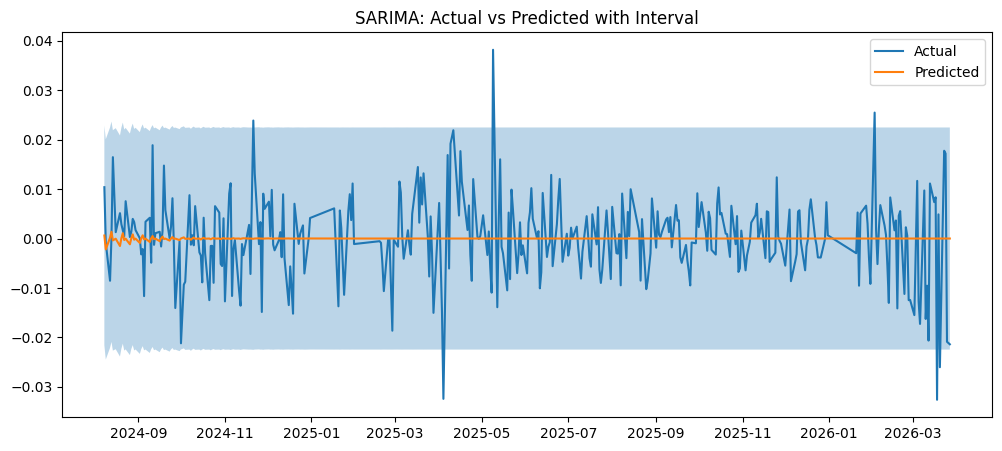

In [17]:
plt.figure(figsize=(12,5))

plt.plot(y_test.index, y_test, label='Actual')
plt.plot(y_test.index, sarima_pred, label='Predicted')

plt.fill_between(
    y_test.index,
    sarima_ci.iloc[:, 0],
    sarima_ci.iloc[:, 1],
    alpha=0.3
)

plt.title("SARIMA: Actual vs Predicted with Interval")
plt.legend()
plt.show()

### SARIMAX PLOT

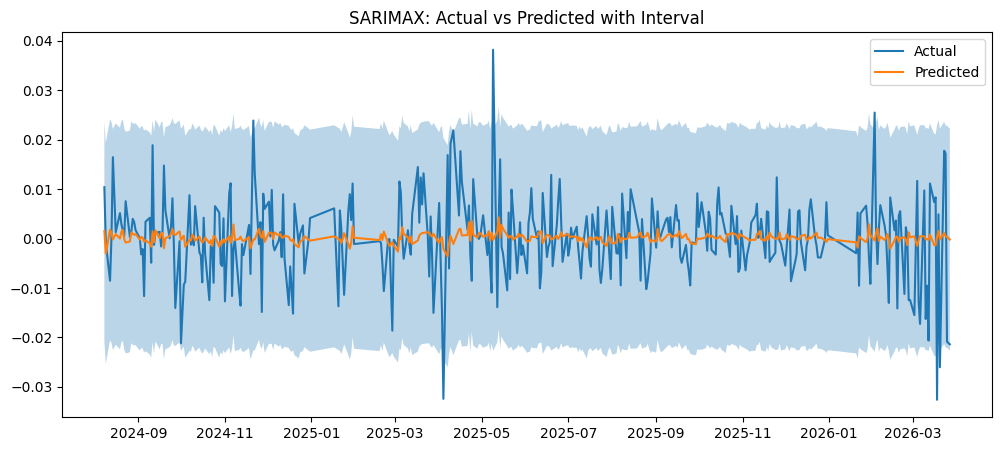

In [18]:
plt.figure(figsize=(12,5))

plt.plot(y_test.index, y_test, label='Actual')
plt.plot(y_test.index, sarimax_pred, label='Predicted')

plt.fill_between(
    y_test.index,
    sarimax_ci.iloc[:, 0],
    sarimax_ci.iloc[:, 1],
    alpha=0.3
)

plt.title("SARIMAX: Actual vs Predicted with Interval")
plt.legend()
plt.show()

In [19]:
combined_output = pd.DataFrame({
    'Date': y_test.index,
    'Actual': y_test.values,
    
    'SARIMA_Pred': sarima_pred.values,
    'SARIMA_Lower': sarima_ci.iloc[:, 0].values,
    'SARIMA_Upper': sarima_ci.iloc[:, 1].values,
    
    'SARIMAX_Pred': sarimax_pred.values,
    'SARIMAX_Lower': sarimax_ci.iloc[:, 0].values,
    'SARIMAX_Upper': sarimax_ci.iloc[:, 1].values
})

combined_output.head(10)

,Date,Actual,SARIMA_Pred,SARIMA_Lower,SARIMA_Upper,SARIMAX_Pred,SARIMAX_Lower,SARIMAX_Upper
0,2024-08-08,0.010387,0.000610,-0.021628,0.022848,0.001521,-0.020768,0.023809
1,2024-08-09,-0.000841,-0.002198,-0.024484,0.020087,-0.003027,-0.025378,0.019324
2,2024-08-12,-0.008543,0.000176,-0.022116,0.022468,0.001776,-0.020575,0.024127
3,2024-08-13,0.000197,0.001373,-0.020920,0.023666,0.001229,-0.021122,0.023580
4,2024-08-14,0.016460,-0.000380,-0.022673,0.021913,-0.000187,-0.022538,0.022164
5,2024-08-16,0.001284,-0.000035,-0.022396,0.022326,0.000913,-0.021484,0.023309
6,2024-08-19,0.005136,-0.001512,-0.023873,0.020850,-0.000002,-0.022400,0.022395
7,2024-08-20,0.002889,0.000066,-0.022295,0.022428,0.001343,-0.021054,0.023741
8,2024-08-21,0.001667,0.001088,-0.021273,0.023450,0.001739,-0.020658,0.024136
9,2024-08-22,0.000470,-0.000304,-0.022665,0.022058,-0.000106,-0.022503,0.022291


In [20]:
pd.set_option('display.float_format', '{:.6f}'.format)
print(combined_output.head(15))

         Date    Actual  SARIMA_Pred  SARIMA_Lower  SARIMA_Upper  \
0  2024-08-08  0.010387     0.000610     -0.021628      0.022848   
1  2024-08-09 -0.000841    -0.002198     -0.024484      0.020087   
2  2024-08-12 -0.008543     0.000176     -0.022116      0.022468   
3  2024-08-13  0.000197     0.001373     -0.020920      0.023666   
4  2024-08-14  0.016460    -0.000380     -0.022673      0.021913   
5  2024-08-16  0.001284    -0.000035     -0.022396      0.022326   
6  2024-08-19  0.005136    -0.001512     -0.023873      0.020850   
7  2024-08-20  0.002889     0.000066     -0.022295      0.022428   
8  2024-08-21  0.001667     0.001088     -0.021273      0.023450   
9  2024-08-22  0.000470    -0.000304     -0.022665      0.022058   
10 2024-08-23  0.007551    -0.000024     -0.022427      0.022380   
11 2024-08-26  0.000286    -0.001171     -0.023574      0.021233   
12 2024-08-27  0.001383     0.000052     -0.022352      0.022455   
13 2024-08-28  0.003976     0.000842     -0.0215

In [21]:
print(sarima_pred.describe())

count   370.000000
mean     -0.000009
std       0.000209
min      -0.002198
25%      -0.000000
50%      -0.000000
75%       0.000000
max       0.001373
Name: predicted_mean, dtype: float64


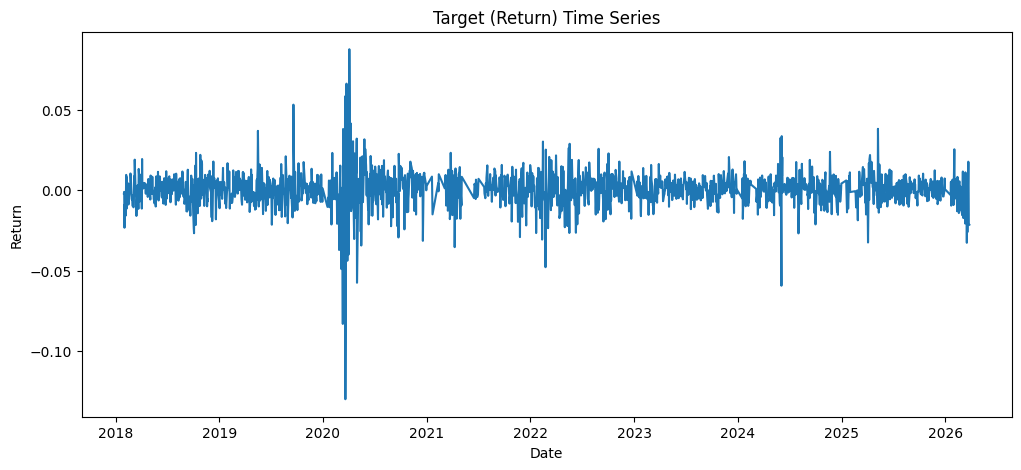

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(df['target'])
plt.title("Target (Return) Time Series")
plt.xlabel("Date")
plt.ylabel("Return")
plt.show()

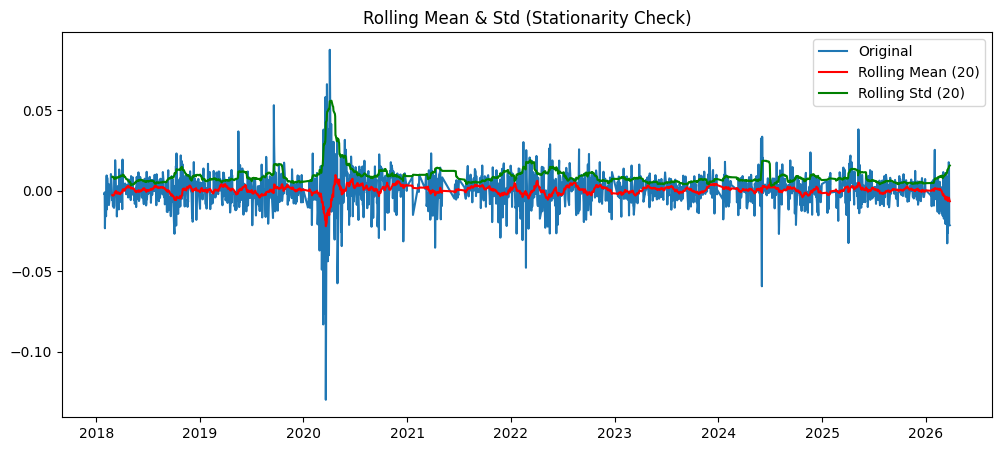

In [23]:
rolling_mean = df['target'].rolling(window=20).mean()
rolling_std = df['target'].rolling(window=20).std()

plt.figure(figsize=(12,5))
plt.plot(df['target'], label='Original')
plt.plot(rolling_mean, label='Rolling Mean (20)', color='red')
plt.plot(rolling_std, label='Rolling Std (20)', color='green')

plt.legend()
plt.title("Rolling Mean & Std (Stationarity Check)")
plt.show()

In [24]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['target'].dropna())

print("ADF Statistic:", result[0])
print("p-value:", result[1])
print("Critical Values:")

for key, value in result[4].items():
    print(f"{key}: {value}")

ADF Statistic: -11.453084497315993
p-value: 5.7940165790631196e-21
Critical Values:
1%: -3.4339167027591952
5%: -2.8631154999882167
10%: -2.5676087418063327
